### Importa los datos
Dataset con diferentes fármacos, sus efectos y ratings de los clientes.

Importa el dataset *drugLibTrain_raw.tsv*

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('data/drugLibTrain_raw.tsv', sep='\t')
data.head()

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


### Descriptive Analysis

Quedate únicamente con las columnas que podamos manejar: Columnas numéricas y columnas categóricas con pocas categorías (menos de 10)

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3107 entries, 0 to 3106
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         3107 non-null   int64 
 1   urlDrugName        3107 non-null   object
 2   rating             3107 non-null   int64 
 3   effectiveness      3107 non-null   object
 4   sideEffects        3107 non-null   object
 5   condition          3106 non-null   object
 6   benefitsReview     3089 non-null   object
 7   sideEffectsReview  3032 non-null   object
 8   commentsReview     3095 non-null   object
dtypes: int64(2), object(7)
memory usage: 218.6+ KB


In [4]:
data.describe()

,Unnamed: 0,rating
count,3107.000000,3107.000000
mean,2080.607016,7.006115
std,1187.998828,2.937582
min,0.000000,1.000000
25%,1062.500000,5.000000
50%,2092.000000,8.000000
75%,3092.500000,9.000000
max,4161.000000,10.000000


In [5]:
for c in data.columns:
    print(c, '-', data[c].nunique())

Unnamed: 0 - 3107
urlDrugName - 502
rating - 10
effectiveness - 5
sideEffects - 5
condition - 1426
benefitsReview - 3031
sideEffectsReview - 2813
commentsReview - 3046


Buscamos valores de las 3 variables con menos de 10 valores para darles valores numéricas

In [6]:
for c in ['effectiveness','sideEffects']:
    print(c)
    print(data[c].unique())

effectiveness
['Highly Effective' 'Marginally Effective' 'Ineffective'
 'Considerably Effective' 'Moderately Effective']
sideEffects
['Mild Side Effects' 'Severe Side Effects' 'No Side Effects'
 'Extremely Severe Side Effects' 'Moderate Side Effects']


In [7]:
drogas = data[['Unnamed: 0','rating','effectiveness','sideEffects']]
drogas.head()

,Unnamed: 0,rating,effectiveness,sideEffects
0,2202,4,Highly Effective,Mild Side Effects
1,3117,1,Highly Effective,Severe Side Effects
2,1146,10,Highly Effective,No Side Effects
3,3947,3,Marginally Effective,Mild Side Effects
4,1951,2,Marginally Effective,Severe Side Effects


#### Transforma las columnas categóricas

Transforma las columnas categoricas a numericas mediante dummies

In [8]:
# EFFECTIVENESS encoder
effectiveness = [
    'Ineffective',
    'Marginally Effective',
    'Moderately Effective',
    'Considerably Effective',
    'Highly Effective'
]

map_eff = {v: i+1 for i, v in enumerate(effectiveness)}
drogas['effectiveness_enc'] = drogas['effectiveness'].map(map_eff)


C:\Users\urkow\AppData\Local\Temp\ipykernel_23428\1100365142.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drogas['effectiveness_enc'] = drogas['effectiveness'].map(map_eff)


In [9]:
# SIDE EFFECTS encoder
effects = [
    'No Side Effects',
    'Mild Side Effects',
    'Moderate Side Effects',
    'Severe Side Effects',
    'Extremely Severe Side Effects'
]

map_effects = {v: i+1 for i, v in enumerate(effects)}
drogas['sideEffects_enc'] = drogas['sideEffects'].map(map_effects)


C:\Users\urkow\AppData\Local\Temp\ipykernel_23428\3489568419.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drogas['sideEffects_enc'] = drogas['sideEffects'].map(map_effects)


In [10]:
drogas.head()

,Unnamed: 0,rating,effectiveness,sideEffects,effectiveness_enc,sideEffects_enc
0,2202,4,Highly Effective,Mild Side Effects,5,2
1,3117,1,Highly Effective,Severe Side Effects,5,4
2,1146,10,Highly Effective,No Side Effects,5,1
3,3947,3,Marginally Effective,Mild Side Effects,2,2
4,1951,2,Marginally Effective,Severe Side Effects,2,4


#### Evalua cual es la mejor K

Utiliza silhouette_score para evaluar cual es la mejor K.

Creamos nuestro conjunto, como queremos todos los datos cogemos X

In [11]:
from sklearn.preprocessing import StandardScaler

X = drogas[['rating', 'effectiveness_enc', 'sideEffects_enc']]

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(3107, 3)


In [12]:
from sklearn.cluster import KMeans

kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
                for k in range(2, 20)]
kmeans_per_k

[KMeans(n_clusters=2, n_init=10, random_state=42),
 KMeans(n_clusters=3, n_init=10, random_state=42),
 KMeans(n_clusters=4, n_init=10, random_state=42),
 KMeans(n_clusters=5, n_init=10, random_state=42),
 KMeans(n_clusters=6, n_init=10, random_state=42),
 KMeans(n_clusters=7, n_init=10, random_state=42),
 KMeans(n_init=10, random_state=42),
 KMeans(n_clusters=9, n_init=10, random_state=42),
 KMeans(n_clusters=10, n_init=10, random_state=42),
 KMeans(n_clusters=11, n_init=10, random_state=42),
 KMeans(n_clusters=12, n_init=10, random_state=42),
 KMeans(n_clusters=13, n_init=10, random_state=42),
 KMeans(n_clusters=14, n_init=10, random_state=42),
 KMeans(n_clusters=15, n_init=10, random_state=42),
 KMeans(n_clusters=16, n_init=10, random_state=42),
 KMeans(n_clusters=17, n_init=10, random_state=42),
 KMeans(n_clusters=18, n_init=10, random_state=42),
 KMeans(n_clusters=19, n_init=10, random_state=42)]

In [13]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_scaled, model.labels_)
                     for model in kmeans_per_k]
silhouette_scores

[0.5239895385002081,
 0.4240291074093128,
 0.38283804903038887,
 0.3893634123418007,
 0.41402515887329583,
 0.4282512461922517,
 0.4529993501468554,
 0.4533889869322991,
 0.515589572746421,
 0.5094046836848963,
 0.5302668442421855,
 0.5302678332611578,
 0.5399997505424641,
 0.556255702825055,
 0.5647689156039158,
 0.5656592308512876,
 0.5652604313525562,
 0.5901270753682384]

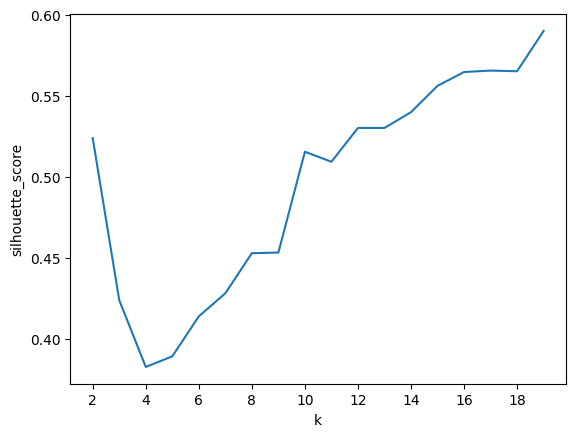

In [17]:
# plt.figure(figsize=(8,3))
plt.plot(range(2,20), silhouette_scores)
plt.xlabel("k")
plt.ylabel("silhouette_score");
plt.xticks(range(2,20,2));

Vemos el elbow en *k=4*

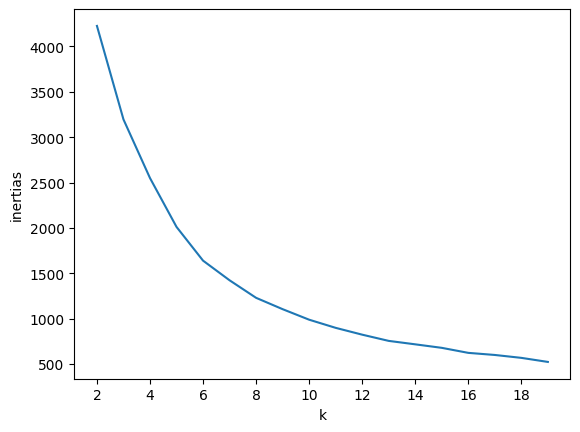

In [16]:
inertias = [model.inertia_ for model in kmeans_per_k]
plt.plot(range(2,20), inertias)
plt.xlabel("k")
plt.ylabel("inertias")
plt.xticks(range(2,20,2));

#### Genera el K Means 

Calculamos para k=4

In [29]:
kmeans_final = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_scaled)
kmeans_final.labels_

array([0, 0, 2, ..., 1, 3, 1], shape=(3107,), dtype=int32)

Guardamos en el df los valores (1, 2, 3, 4)

In [32]:
drogas = X.copy()
drogas['cluster'] = kmeans_final.labels_ + 1
drogas.head()

,rating,effectiveness_enc,sideEffects_enc,cluster
0,4,5,2,1
1,1,5,4,1
2,10,5,1,3
3,3,2,2,2
4,2,2,4,2


Vemos qué distribución de valores de cluster hay

In [33]:
drogas['cluster'].value_counts()

cluster
3    1077
4     815
1     695
2     520
Name: count, dtype: int64

#### Comprueba los resultados y muestra en un pie plot la distribución de los distintos clusters.

Dibujamos pie con los valores de cluster

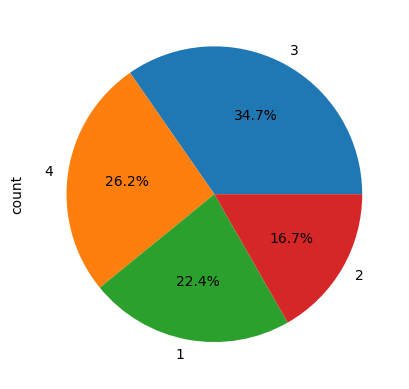

In [36]:
drogas['cluster'].value_counts().plot.pie(autopct="%.1f%%");

Dibujamos siluets

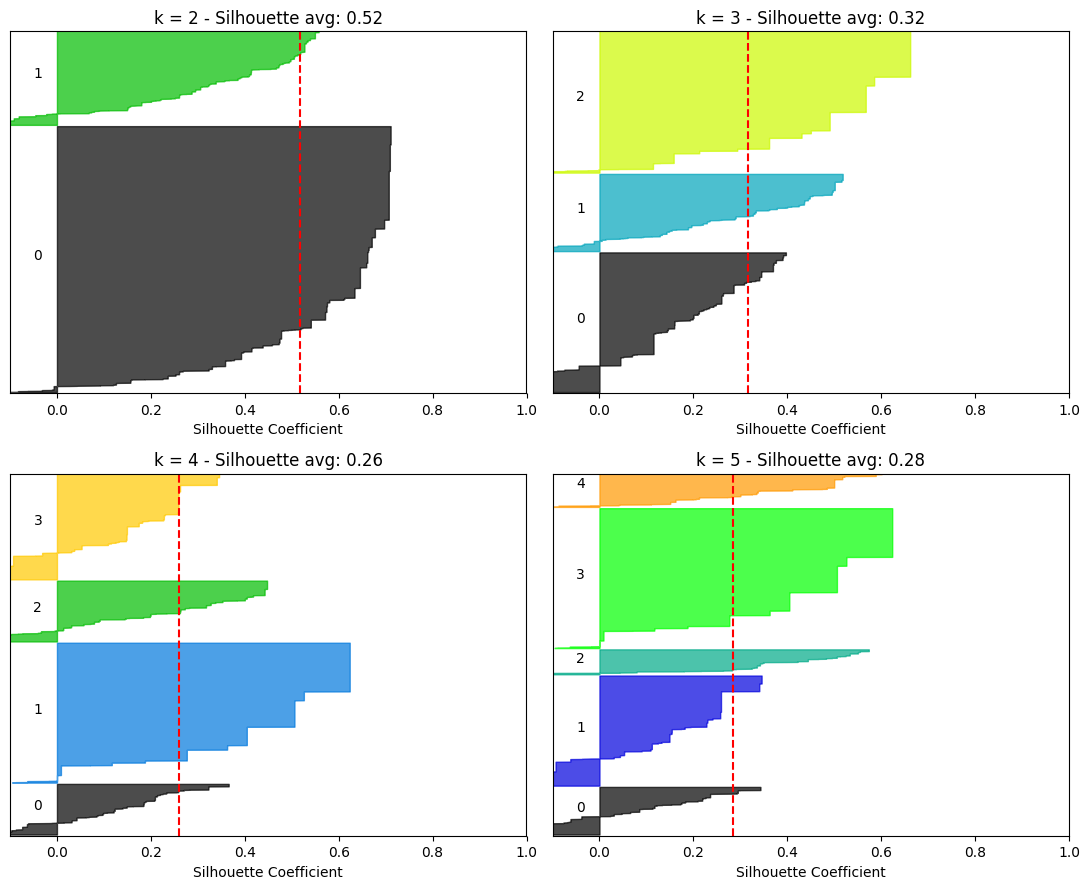

In [41]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# Configurar figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(11, 9))
axes = axes.flatten()

for i, k in enumerate(range(2, 6)):
    ax = axes[i]
    kmeans = kmeans_per_k[i]  
    labels = kmeans.labels_
    
    silhouette_vals = silhouette_samples(X_scaled, labels)
    silhouette_avg = silhouette_score(X_scaled, labels)
    y_lower = 10

    for cluster in range(k):
        cluster_sil_vals = silhouette_vals[labels == cluster]
        cluster_sil_vals.sort()
        size = len(cluster_sil_vals)
        y_upper = y_lower + size
        color = cm.nipy_spectral(float(cluster) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * size, str(cluster))
        y_lower = y_upper + 10

    ax.axvline(silhouette_avg, color="red", linestyle="--")
    ax.set_title(f'k = {k} - Silhouette avg: {silhouette_avg:.2f}')
    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_scaled)])
    ax.set_yticks([])
    ax.set_xlabel("Silhouette Coefficient")


plt.tight_layout()
plt.show();